In [1]:
from qg import QG
from sw import SW

import numpy as np
import xarray as xr 
import os, sys
sys.path.insert(0, '../model_qg1l')
import jqgm
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

import jax.numpy as jnp

import matplotlib.pyplot as plt

In [2]:
ds = xr.open_dataset('/Data2/2020a_SSH_mapping_NATL60/dc_ref/NATL60-CJM165_GULFSTREAM_y2012m10d01.1h_SSH.nc')
ds = ds.coarsen(lon=3, lat=3, time=24).mean()
lon = ds.lon.values
lat = ds.lat.values
ssh0 = ds.sossheig.squeeze()
ssh0.plot()
ssh0 = ssh0.values

FileNotFoundError: [Errno 2] No such file or directory: '/Data2/2020a_SSH_mapping_NATL60/dc_ref/NATL60-CJM165_GULFSTREAM_y2012m10d01.1h_SSH.nc'

In [ ]:
ds = xr.open_dataset('/home/eouser/Git/MASSH/mapping/aux/aux_first_baroclinic_speed.nc')
ds = ds.assign_coords({'lon':(('lon', (ds['lon'].data + 180) % 360 - 180 ))})
ds = ds.sortby('lon')
ds = ds.sel(lon=slice(lon.min(), lon.max()), lat=slice(lat.min(), lat.max()))
c1 = np.float64(ds.c1.mean())
H0 = np.abs(np.float64(ds.H.mean()))
c1, H0


(2.6402393824082866, 4919.6675900277005)

In [ ]:
dtype = np.float64

## Space discretization definition -------------------------------------------
nx = lon.size
ny = lat.size
nl = 1
L = 1000000  # 100km
Lx = L
Ly = L
dx = Lx / nx
dy = Ly / ny
x_, y_ = (
    np.linspace(-Lx / 2, Lx / 2, nx + 1),
    np.linspace(-Ly / 2, Ly / 2, ny + 1),
)
x, y = np.meshgrid(x_, y_, indexing="ij")
## ---------------------------------------------------------------------------

## Layers Reference thickness definition -------------------------------------
# H = torch.zeros(nl, 1, 1, dtype=dtype, device=device)
# if nl == 1:
#     H[0, 0, 0] = 1000  # 1km
# 1-layer reduced gravity
H = np.array([[[H0]]])
## ---------------------------------------------------------------------------

## Reduced Gravity definition ------------------------------------------------
# g_prime = torch.zeros(nl, 1, 1, dtype=dtype, device=device)
# if nl == 1:
#     g_prime[0, 0, 0] = 10.0
# 1-layer reduced gravity
g_prime = np.array([[[c1**2/H0]]])
## ---------------------------------------------------------------------------


## Circular Mask definition --------------------------------------------------
xc_ = 0.5 * (x_[1:] + x_[:-1])
yc_ = 0.5 * (y_[1:] + y_[:-1])
xc, yc = np.meshgrid(xc_, yc_, indexing="ij")
rc = np.sqrt(xc**2 + yc**2)
# domain mask
mask = np.ones_like(xc)
## ---------------------------------------------------------------------------

# density/gravity
rho = 1000.0

flip_sign = False

# Burger and Rossby
Bu, Ro = 1., .1

r0, r1, r2 = 0.1 * Lx, 0.1 * Lx, 0.14 * Lx

# set coriolis with burger number
f0 = 1e-4
if flip_sign:
    f0 *= -1
beta = 0
f = f0 + beta * (y - Ly / 2)

# wind forcing, bottom drag
taux = 0.0
tauy = 0.0
bottom_drag_coef = 0.0

dt = 600

## Model Parameters Definition -------------------------------------------

### QG Model
param_qg = {
    "nx": nx,
    "ny": ny,
    "nl": nl,
    "dx": dx,
    "dy": dy,
    "H": H,
    "g_prime": g_prime,
    "f": f,
    "taux": taux,
    "tauy": tauy,
    "bottom_drag_coef": bottom_drag_coef,
    "dtype": dtype,
    "mask": mask,
    "compile": True,
    "slip_coef": 0.,
    "dt": dt,
}

In [ ]:
qg_old = jqgm.Qgm(dx=dx*np.ones((ny,nx)), dy=dy*np.ones((ny,nx)), dt=dt, SSH=None, c=c1, Kdiffus=None, upwind=3, g=9.81, f=f0*np.ones((ny,nx)))

In [ ]:
## Create QG model -------------------------------------------------------
qg = QG(param_qg)
## -----------------------------------------------------------------------

Creating QG model...
  - nx, ny, nl =  (200, 200, 1)
  - trivial mask provided
  - no-slip boundary condition
  - integration time step 6.000e+02
  - Rossby deformation Radii (km):  26.402393824082854


In [ ]:
g = 9.81
p_init = jnp.array(g * ssh0, dtype=dtype)
p_init = jnp.pad(p_init, pad_width=((1, 0), (1, 0)))
p_init = p_init[None, None, :, :]

u_init, v_init, h_init = qg.G(p_init)

In [ ]:
def h2ssh(h):

    A_inv = jnp.linalg.inv(qg.A)  # shape: (m, l)
    E = h / (qg.H)   # shape: (..., l, x, y)
    p_i = jnp.einsum('ml,...lxy->...mxy', A_inv, E)

    return p_i/g  # shape: (..., x, y)

def ssh2h(ssh):
    """
    Computes h (..., l, x, y) from ssh (..., m, x, y).
    """
    A = qg.A                   # (m, l)
    H = qg.H                   # (l,)
    p_i = ssh * g              # (..., m, x, y)
    
    # Compute E = A @ p_i
    E = jnp.einsum('lm,...mxy->...lxy', A, p_i)   # (..., l, x, y)
    
    h = E * H   # broadcast H over x, y: H[l] * E[..., l, x, y]
    
    return h                   # (..., l, x, y)

t =  0.0 days


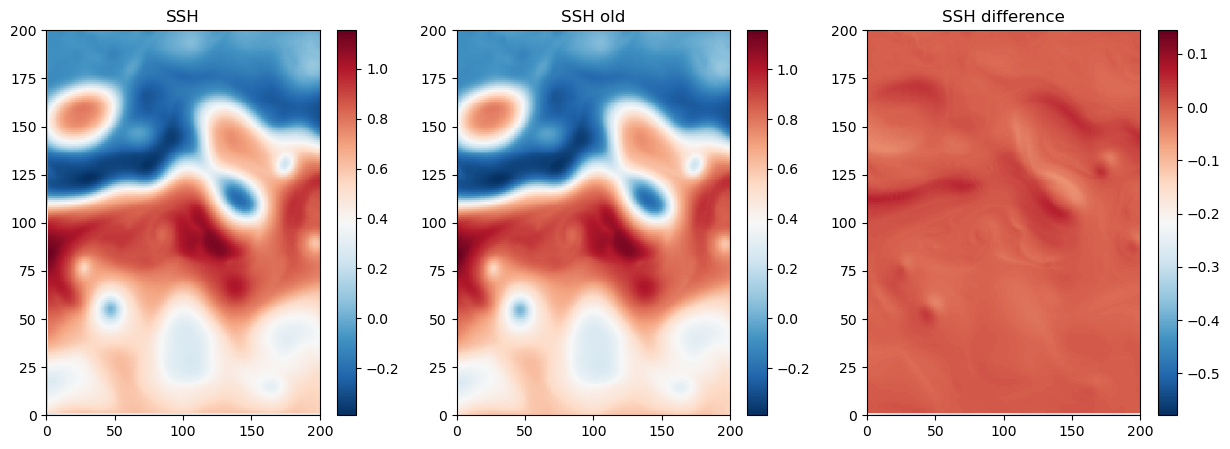

t =  1.0 days


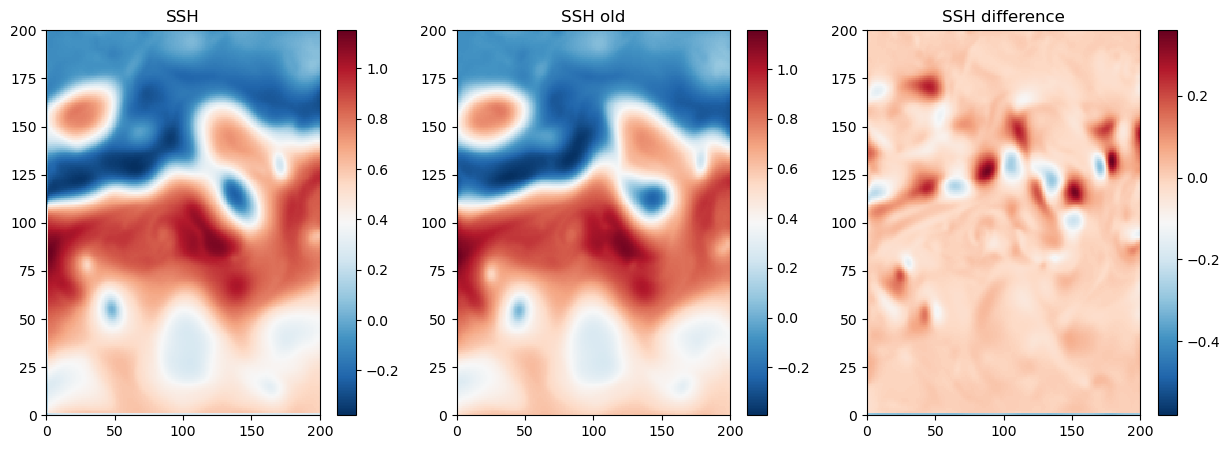

t =  2.0 days


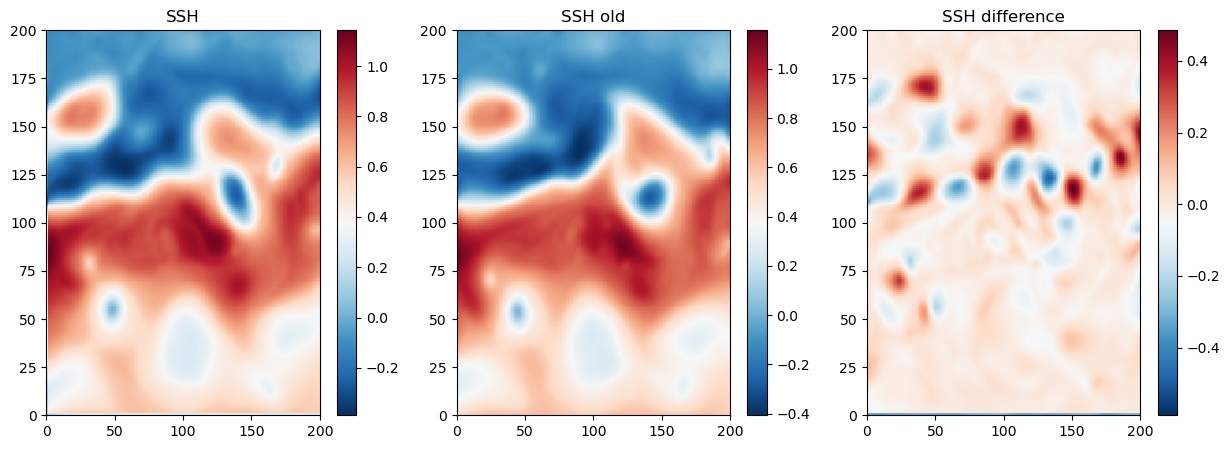

t =  3.0 days


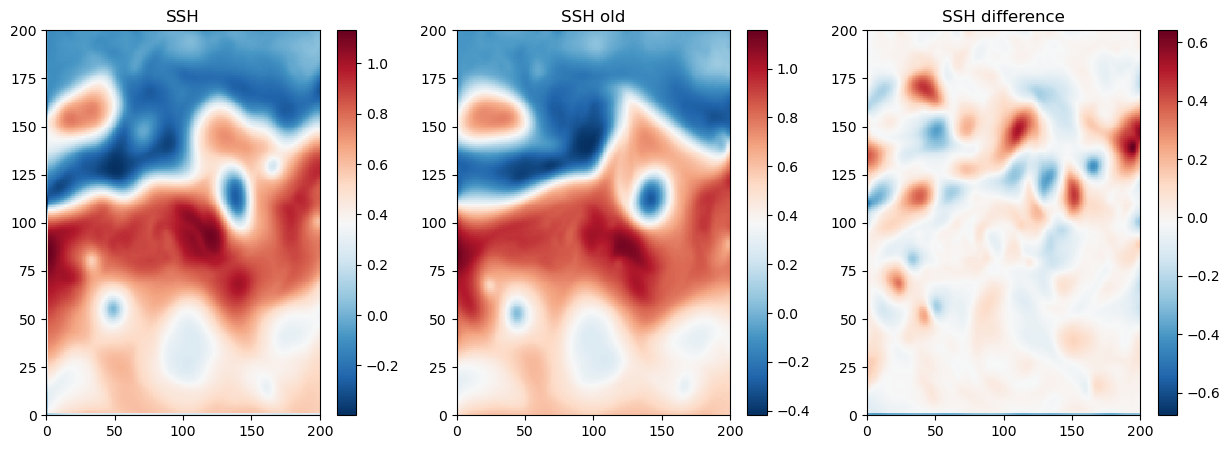

t =  4.0 days


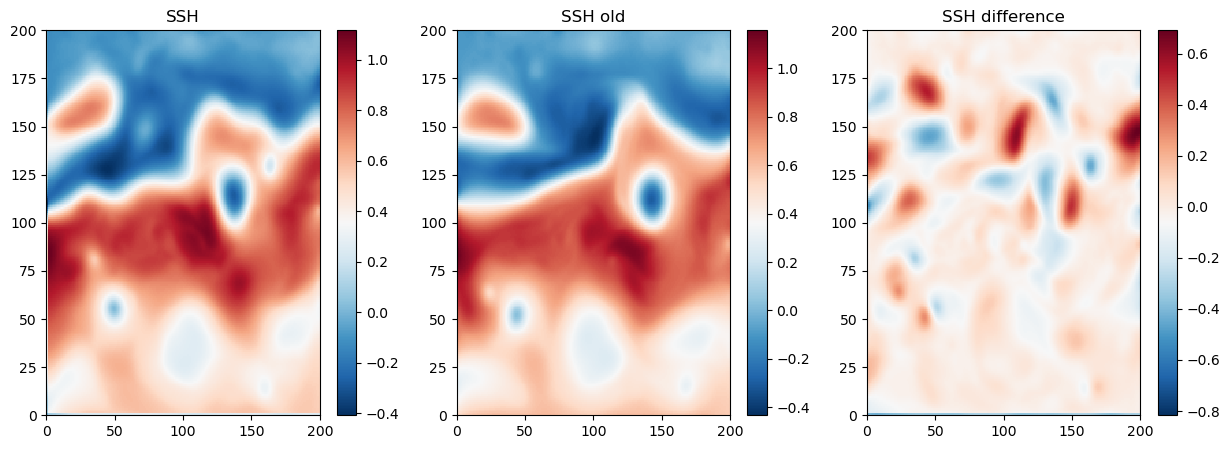

t =  5.0 days


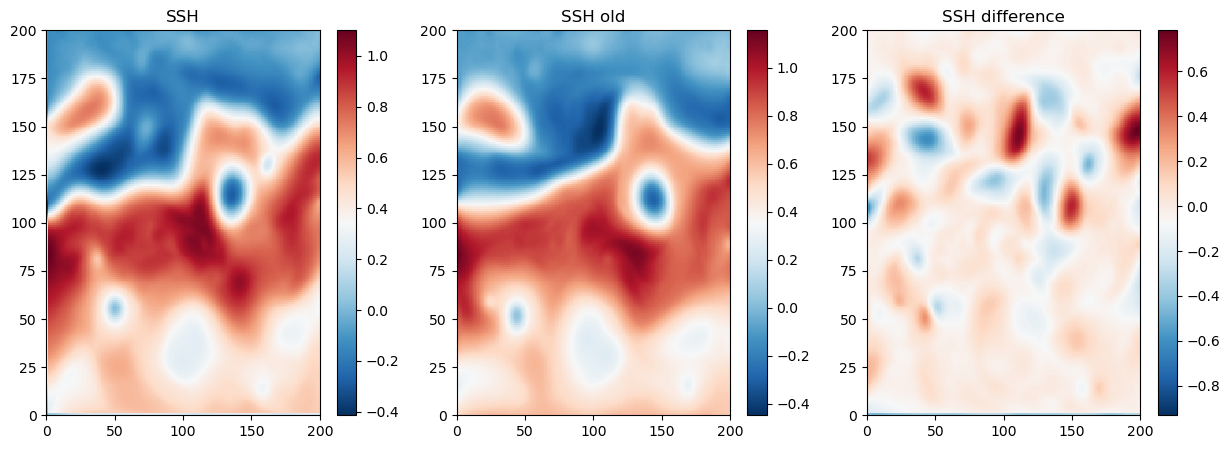

t =  6.0 days


KeyboardInterrupt: 

In [ ]:
ndays = 10
nplot = 1
t = 0

u = +u_init / qg.dx
v = +v_init / qg.dy
h = +h_init / qg.area
ssh = h2ssh(h)
ssh_old = ssh0
sshb = +ssh0

while t<ndays*24*3600:

    if t % (nplot*24*3600) == 0:
        print("t = ", t/24/3600, 'days')

        fig, (ax1,ax2,ax3) = plt.subplots(1,3, figsize=(15, 5))
        im1 = ax1.pcolormesh(ssh[0,0], cmap='RdBu_r')
        ax1.set_title('SSH')
        plt.colorbar(im1, ax=ax1)
        im2 = ax2.pcolormesh(ssh_old, cmap='RdBu_r')
        ax2.set_title('SSH old')
        plt.colorbar(im2, ax=ax2)
        im3 = ax3.pcolormesh(ssh[0,0] - ssh_old, cmap='RdBu_r')
        ax3.set_title('SSH difference')
        plt.colorbar(im3, ax=ax3)
        plt.show()
        plt.pause(0.05)

    ssh_old = qg_old.step(ssh_old, sshb)
    u, v, h, ssh = qg.step(u, v, h, return_ssh=True)
    t += qg.dt

In [ ]:
ssh0.shape

(200, 200)